<a href="https://colab.research.google.com/github/Calrission/MIIGAIK-Image-Processing/blob/master/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%962_%D0%9F%D1%80%D0%B8%D0%BC%D0%B5%D0%BD%D0%B5%D0%BD%D0%B8%D0%B5_%D0%BC%D0%B5%D1%82%D0%BE%D0%B4%D0%B0_%C2%AB%D1%81%D0%BA%D0%BE%D0%BB%D1%8C%D0%B7%D1%8F%D1%89%D0%B5%D0%B3%D0%BE_%D0%BE%D0%BA%D0%BD%D0%B0%C2%BB_%D0%B4%D0%BB%D1%8F_%D0%BF%D0%BE%D0%B8%D1%81%D0%BA%D0%B0_%D0%BE%D0%B1%D1%8A%D0%B5%D0%BA%D1%82%D0%BE%D0%B2_%D0%BD%D0%B0_%D0%B8%D0%B7%D0%BE%D0%B1%D1%80%D0%B0%D0%B6%D0%B5%D0%BD%D0%B8%D0%B8_%D0%BF%D0%BE_%D1%8D%D1%82%D0%B0%D0%BB%D0%BE%D0%BD%D0%B0%D0%BC_%D0%B2_%D1%81%D1%80%D0%B5%D0%B4%D0%B5_Python_%D0%9D%D0%B5%D0%BB%D0%B8%D0%BD%D0%B5%D0%B8%CC%86%D0%BD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №2. Применение метода «скользящего окна» для поиска объектов на изображении по эталонам в среде Python. Нелинейные фильтры**

### **Задание №1. Найти пять зашумленных изображений и применить к ним вышеописанные фильтры. Сравнить полученные результаты. Сделать вывод для шумов какого типа целесообразней применение того или иного фильтра**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

path_dir = "static\\2"
samples = ['1.png', '2.jpg', '3.webp', '4.jpg', '5.webp', '6.png']

for name in samples:
    image = cv2.imread(path_dir + '\\' + name)

    median_image = cv2.medianBlur(image, 3)

    kernel = np.ones((3, 3), np.float32) / 9
    avg_image = cv2.filter2D(image, -1, kernel)

    plt.figure(figsize = (15, 5))
    plt.subplot(1, 3, 1)
    plt.title('Оригинал')
    plt.axis('off')
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

    plt.subplot(1, 3, 2)
    plt.title('Медианный фильтр')
    plt.axis('off')
    plt.imshow(cv2.cvtColor(median_image, cv2.COLOR_BGR2RGB))

    plt.subplot(1, 3, 3)
    plt.title('Средний фильтр')
    plt.axis('off')
    plt.imshow(cv2.cvtColor(avg_image, cv2.COLOR_BGR2RGB))

    plt.show()


### **Задание №2. Из подкаталога «Image_1» (каталога IMAGE), определить местонахождение всех фрагментов (Et_1.png - Et_10.png) на растре IMAGE.jpg, используя вышеописанный алгоритм. Вывести результаты в консоль по каждому эталону**

**Ссылка на Image_1: https://cloud.mail.ru/public/EA1a/sV96pAxaH**

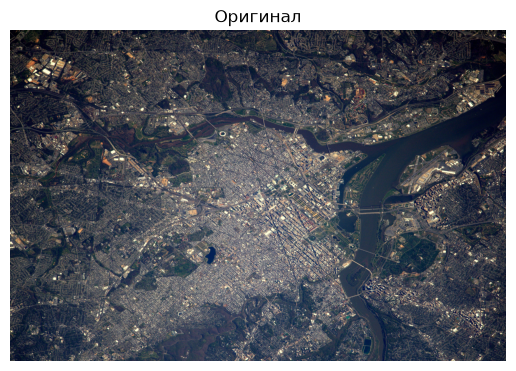

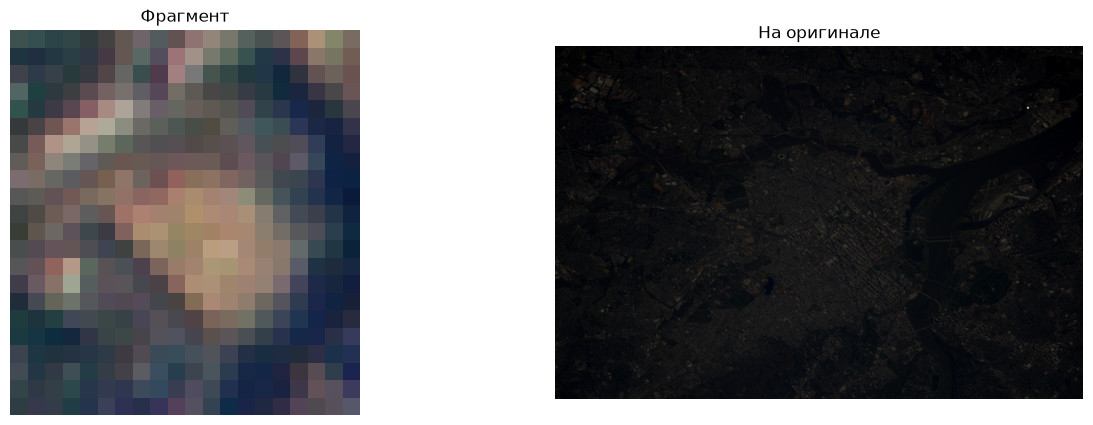

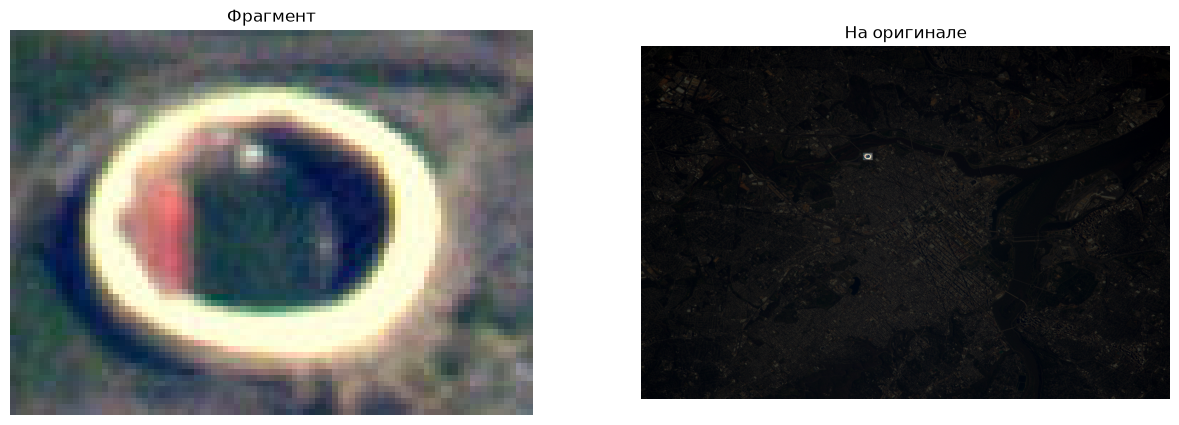

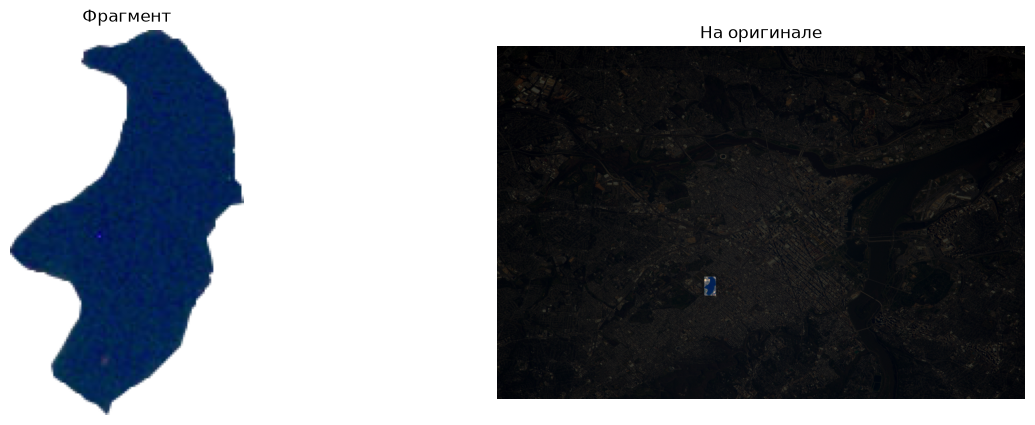

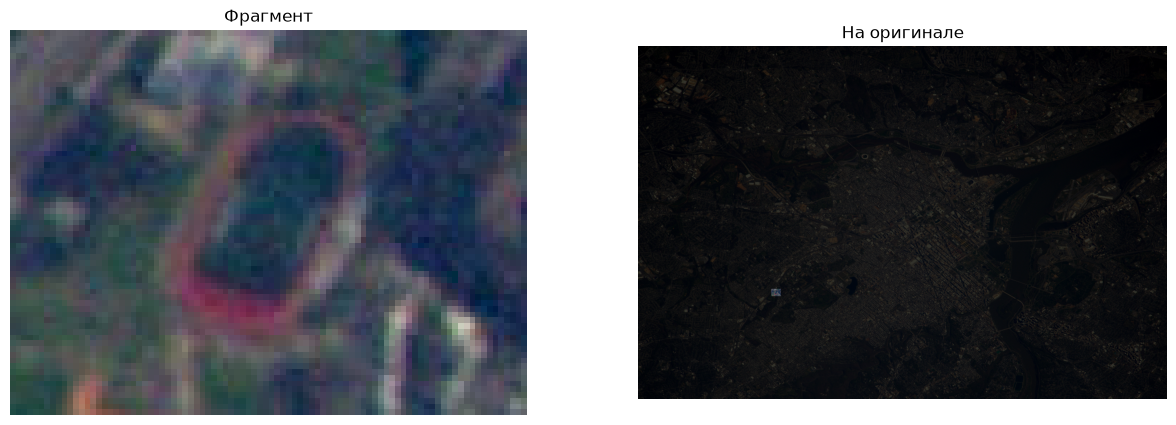

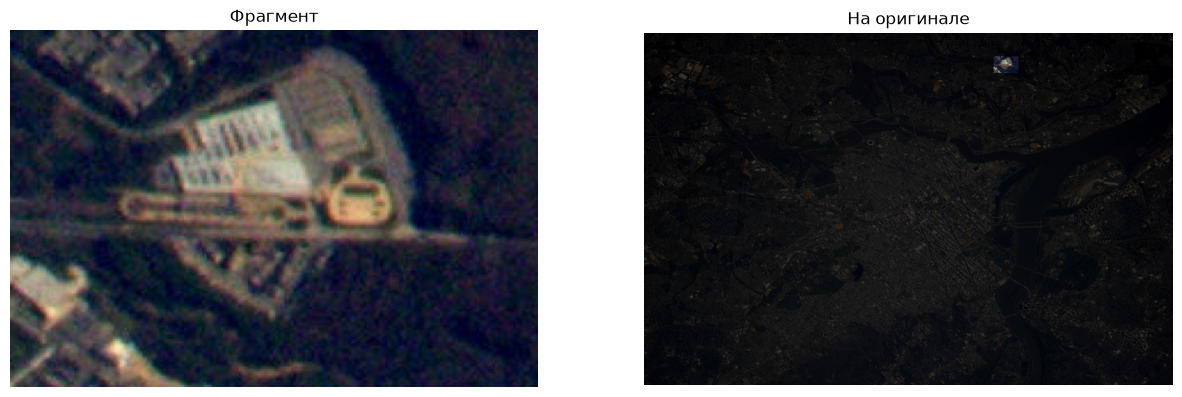

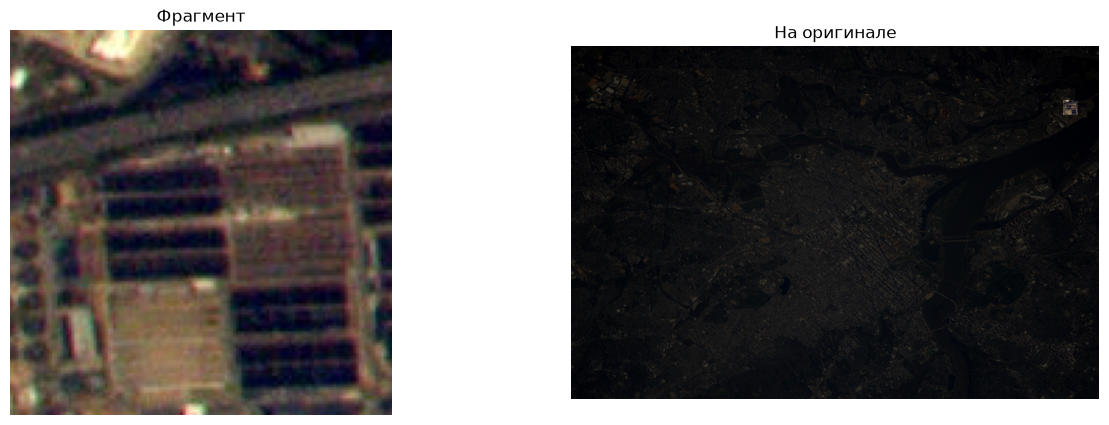

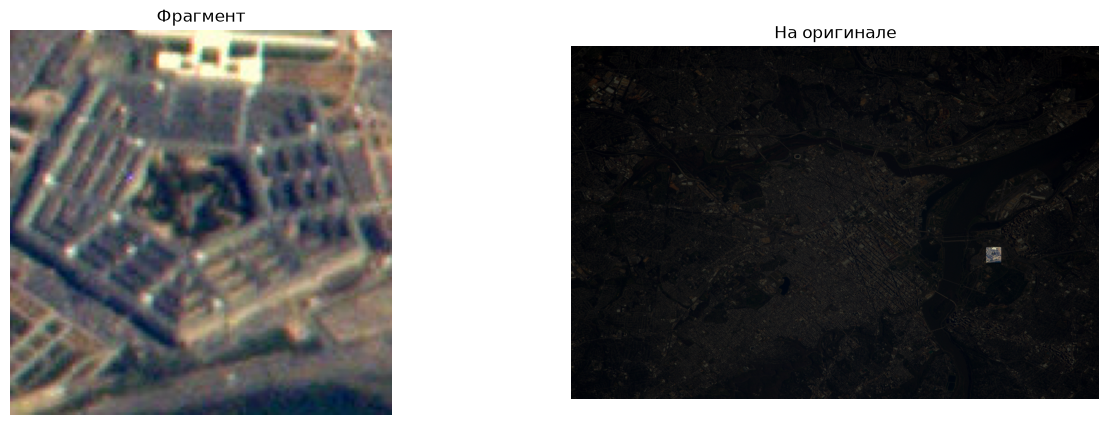

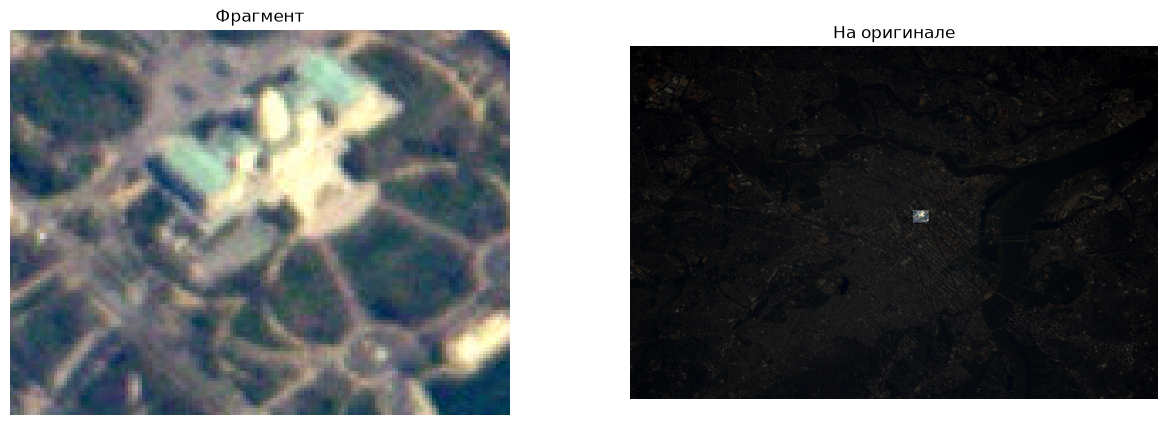

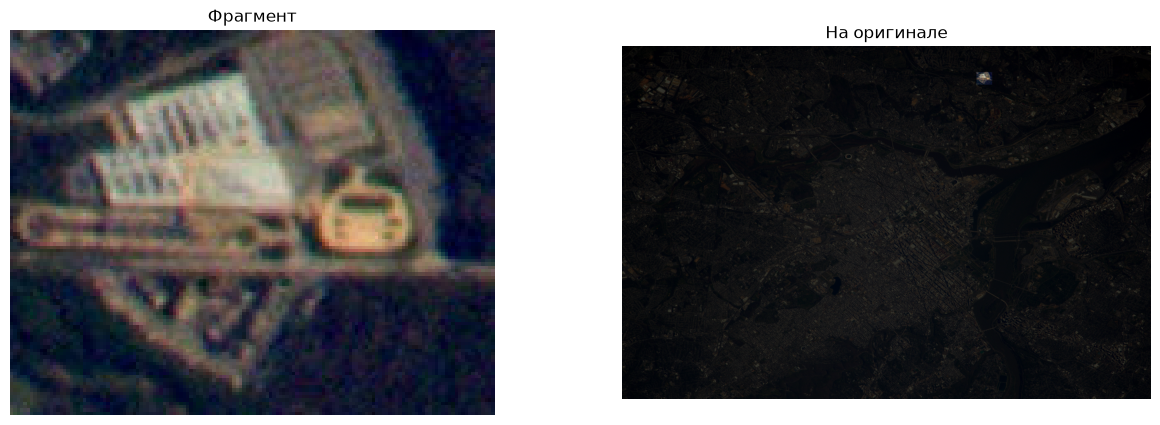

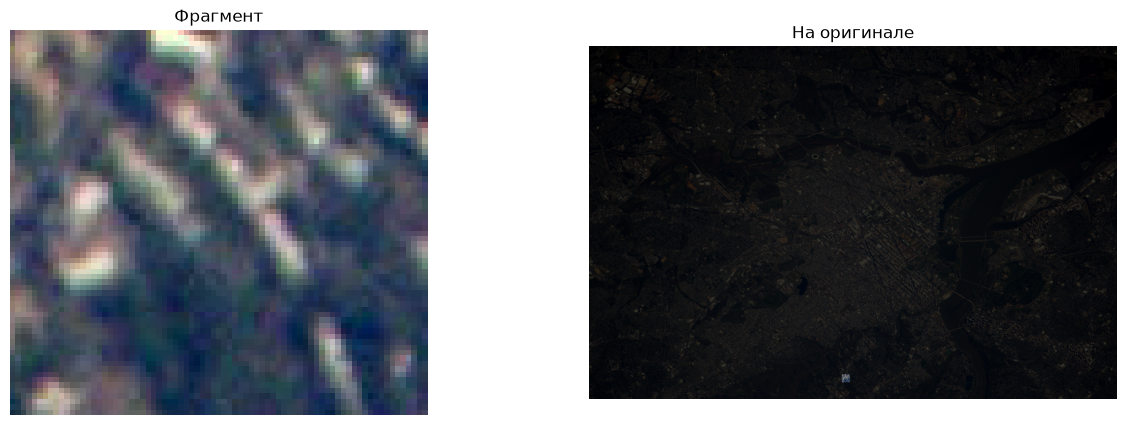

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

path_dir = "static\\2\\Image_1\\"
image = cv2.imread(path_dir + 'IMAGE.jpg')
plt.title("Оригинал")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

samples = ['Et_1.png', 'Et_2.png', 'Et_3.png', 'Et_4.png', 'Et_5.png', 'Et_6.png', 'Et_7.png', 'Et_8.png', 'Et_9.png', 'Et_10.png']
for name in samples:
    fragment = cv2.imread(path_dir + '\\' + name)
    (fragmentHeight, fragmentWidth) = fragment.shape[:2]
    result = cv2.matchTemplate(image, fragment, cv2.TM_CCOEFF)
    (_, _, minLoc, maxLoc) = cv2.minMaxLoc(result)

    topLeft = maxLoc
    botRight = (topLeft[0] + fragmentWidth, topLeft[1] + fragmentHeight)
    roi = image[topLeft[1]:botRight[1], topLeft[0]:botRight[0]].copy()

    mask = np.zeros(image.shape, dtype="uint8")
    image_dark = cv2.addWeighted(image, 0.2, mask, 0.75, 0)

    image_dark[topLeft[1]:botRight[1], topLeft[0]:botRight[0]] = roi

    max_height = 950
    if image_dark.shape[0] > max_height:
        scale = max_height / image_dark.shape[0]
        image_display = cv2.resize(image_dark, None, fx=scale, fy=scale)
    else:
        image_display = image_dark

    plt.figure(figsize = (15, 5))
    plt.subplot(1, 2, 1)
    plt.axis('off')
    plt.title("Фрагмент")
    plt.imshow(cv2.cvtColor(fragment, cv2.COLOR_BGR2RGB))
    plt.subplot(1, 2, 2)
    plt.axis('off')
    plt.title("На оригинале")
    plt.imshow(cv2.cvtColor(image_display, cv2.COLOR_BGR2RGB))
    plt.show()

### **Задание №3. Создать свой эталон (фрагмент), а затем определить его местонахождение на растре (по образцу из примера выше).**

**Главное при создании фрагмента учесть его разрешение.**

Можно создать эталон на сайте: https://convert-my-image.com/CropImage_Ru или используя срезы NumPy.

In [ ]:
# Ваш код

